In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the data
df = pd.read_csv('Loan.csv')

# Handle missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Convert Dependents to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Encode categorical variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
df['Property_Area'] = le.fit_transform(df['Property_Area'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

# Check for remaining missing values
print(df.isnull().sum())

# Preview cleaned data
df.head()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipython-input-1207564486.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipython-input-1207564486.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


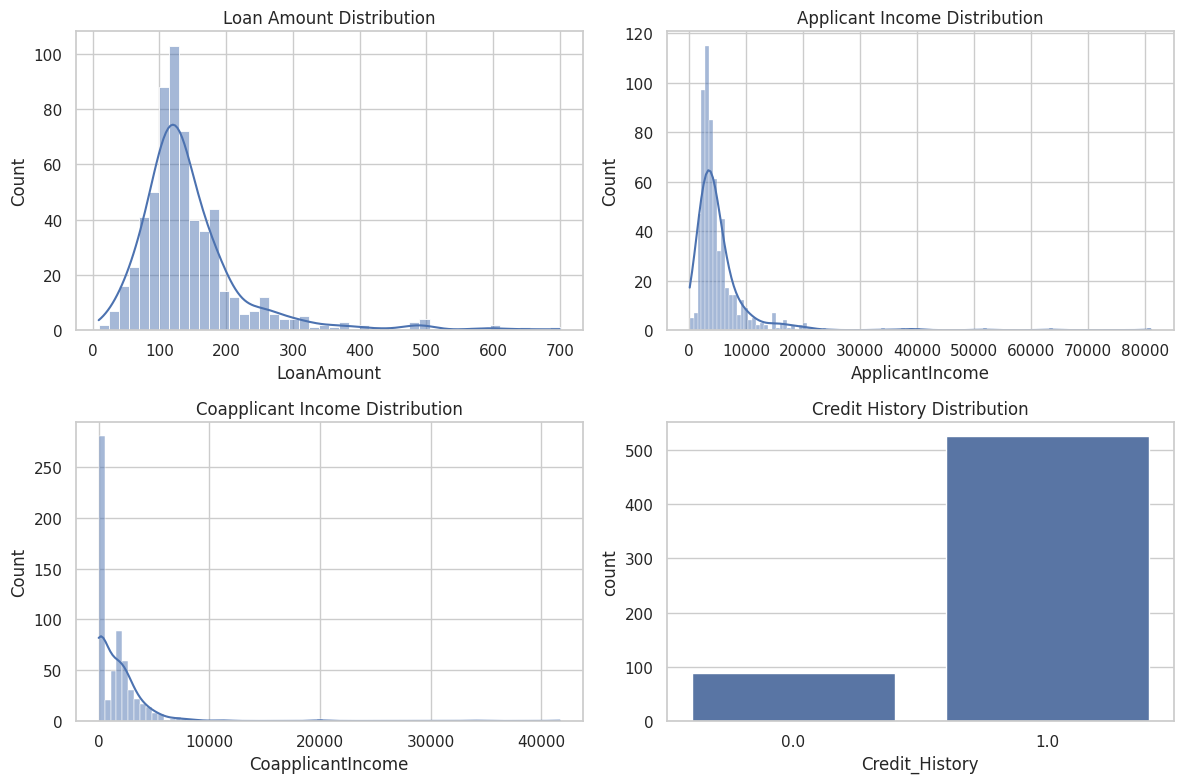

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Distributions
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Loan Amount Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Applicant Income Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['CoapplicantIncome'], kde=True)
plt.title('Coapplicant Income Distribution')

plt.subplot(2, 2, 4)
sns.countplot(x='Credit_History', data=df)
plt.title('Credit History Distribution')

plt.tight_layout()
plt.show()

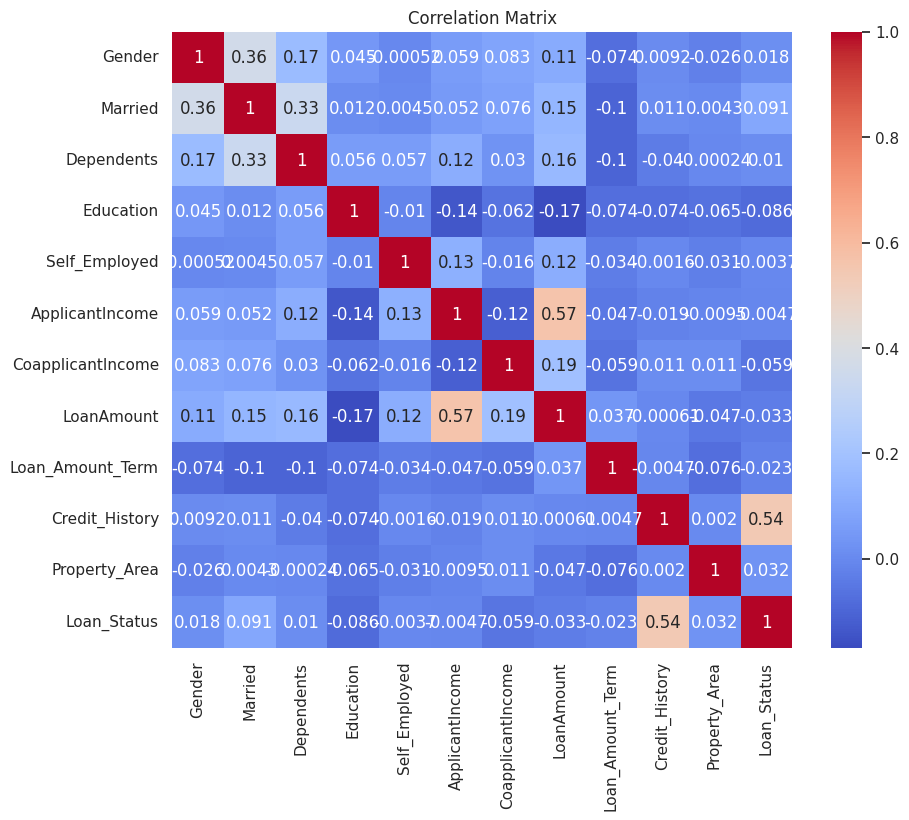

In [15]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

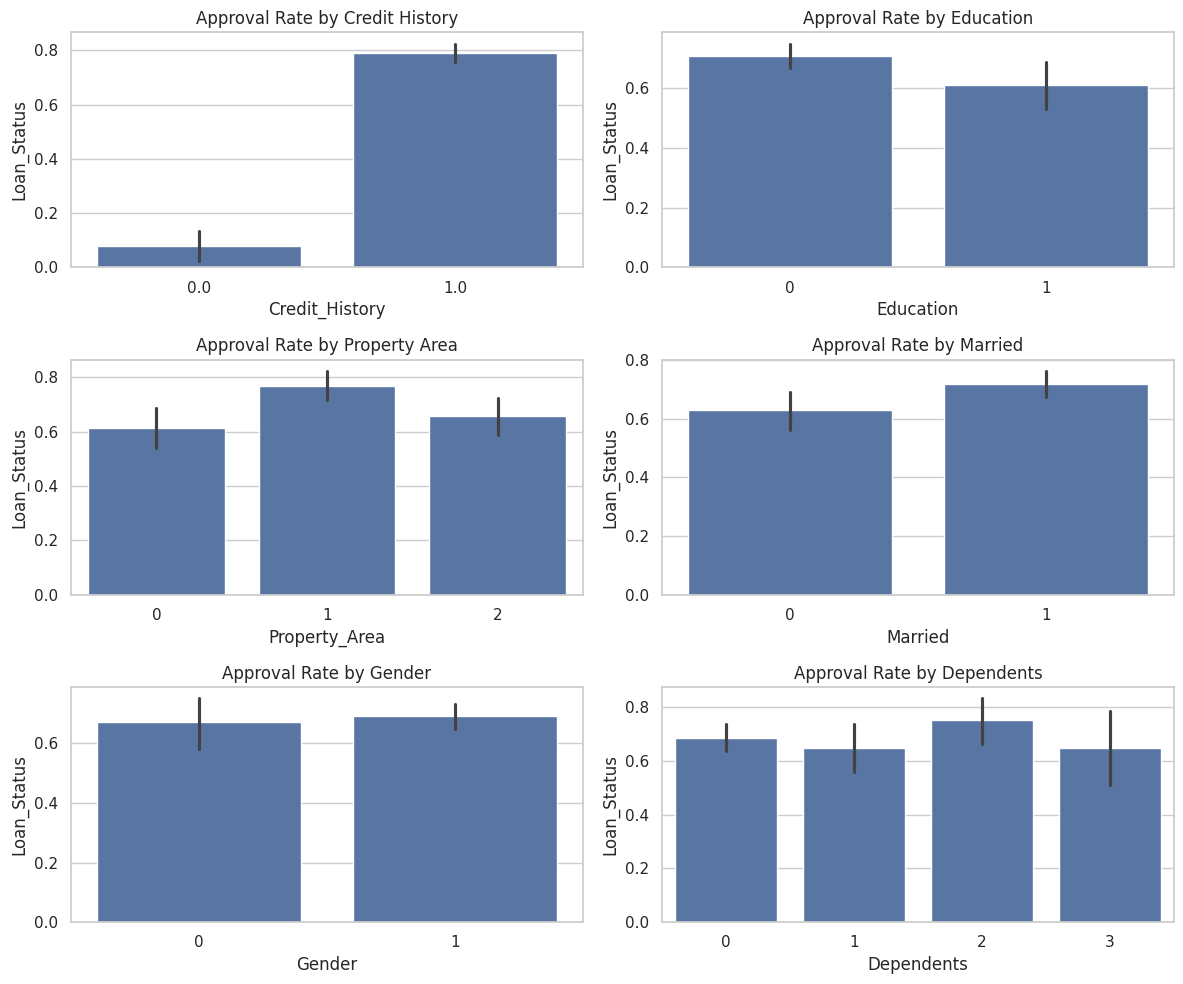

In [16]:
# Approval rates
plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
sns.barplot(x='Credit_History', y='Loan_Status', data=df)
plt.title('Approval Rate by Credit History')

plt.subplot(3, 2, 2)
sns.barplot(x='Education', y='Loan_Status', data=df)
plt.title('Approval Rate by Education')

plt.subplot(3, 2, 3)
sns.barplot(x='Property_Area', y='Loan_Status', data=df)
plt.title('Approval Rate by Property Area')

plt.subplot(3, 2, 4)
sns.barplot(x='Married', y='Loan_Status', data=df)
plt.title('Approval Rate by Married')

plt.subplot(3, 2, 5)
sns.barplot(x='Gender', y='Loan_Status', data=df)
plt.title('Approval Rate by Gender')

plt.subplot(3, 2, 6)
sns.barplot(x='Dependents', y='Loan_Status', data=df)
plt.title('Approval Rate by Dependents')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Features and target
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Train
for name, model in models.items():
    model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:
Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
F1 Score: 0.8586956521739131
Confusion Matrix:
 [[18 25]
 [ 1 79]]


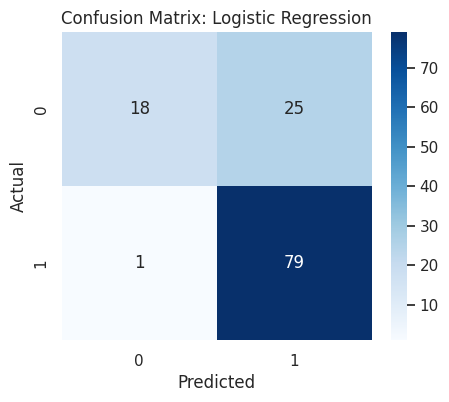


KNN:
Accuracy: 0.5772357723577236
Precision: 0.6320754716981132
Recall: 0.8375
F1 Score: 0.7204301075268817
Confusion Matrix:
 [[ 4 39]
 [13 67]]


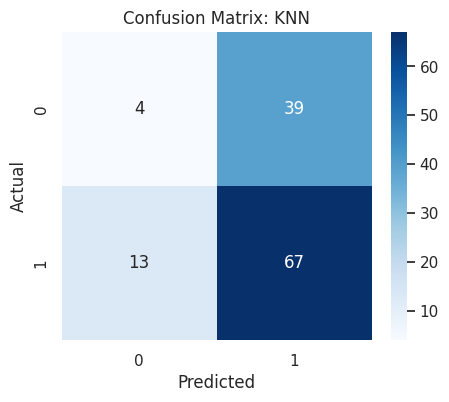


SVM:
Accuracy: 0.6504065040650406
Precision: 0.6504065040650406
Recall: 1.0
F1 Score: 0.7881773399014779
Confusion Matrix:
 [[ 0 43]
 [ 0 80]]


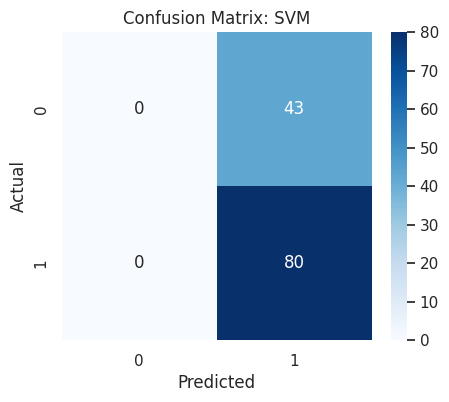


Decision Tree:
Accuracy: 0.6910569105691057
Precision: 0.75
Recall: 0.7875
F1 Score: 0.7682926829268293
Confusion Matrix:
 [[22 21]
 [17 63]]


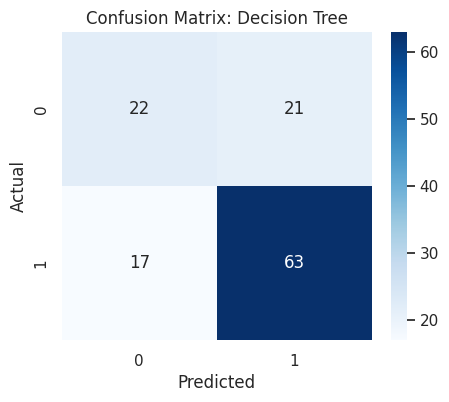


Random Forest:
Accuracy: 0.7723577235772358
Precision: 0.7549019607843137
Recall: 0.9625
F1 Score: 0.8461538461538461
Confusion Matrix:
 [[18 25]
 [ 3 77]]


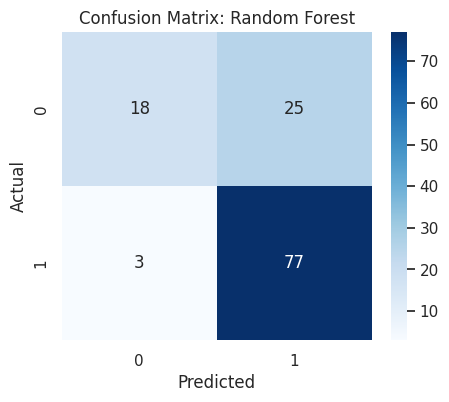

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'\n{name}:')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1 Score:', f1_score(y_test, y_pred))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()